# Chicago 311 Service Requests - MongoDB Analiza

**Autori:** Marko Zelić IN48-2022, Uroš Ogrizović IN12-2022  
**Predmet:** Sistemi baza podataka, FTN Novi Sad  
**Dataset:** Chicago 311 Service Requests (~1.3 GB, 12 CSV fajlova, 4M+ redova)

---

## 1. Imports

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import json
from pprint import pprint

import connection
import load_data
import base_queries
import optimized_queries
import optimize_schema
import query_executor

/home/uros/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. MongoDB konekcija

In [2]:
MONGO_URI = "mongodb://localhost:27017/"
MONGO_DATABASE_NAME = "chicago_311_db"

client, database = connection.connect_to_mongodb(MONGO_URI, MONGO_DATABASE_NAME)

Povezan na MongoDB: mongodb://localhost:27017/
Baza podataka: chicago_311_db


## 3. Učitavanje podataka

Učitavanje 12 CSV fajlova u 6 normalizovanih kolekcija:
- `requests` - zajednička polja svih zahteva
- `locations` - deduplikovani geografski podaci
- `vehicle_details` - detalji napuštenih vozila
- `sanitation_details` - sanitarni detalji (glodavci, đubre, kodne povrede)
- `environment_details` - infrastruktura i okruženje (rupe, svetla, grafiti, drveće)
- `building_details` - detalji napuštenih zgrada

In [3]:
load_data.drop_all_collections(database)
stats = load_data.load_all_data(database)

Sve kolekcije obrisane.

Ucitavanje: 311-service-requests-abandoned-vehicles.csv
  Redova u CSV: 242,734


  311-service-requests-abandoned: 100%|████████████████████████████████████████████████████████████████████| 242734/242734 [00:35<00:00, 6791.57it/s]



Ucitavanje: 311-service-requests-alley-lights-out.csv
  Redova u CSV: 219,010


  311-service-requests-alley-lig: 100%|████████████████████████████████████████████████████████████████████| 219010/219010 [00:26<00:00, 8380.76it/s]



Ucitavanje: 311-service-requests-garbage-carts.csv
  Redova u CSV: 403,791


...


Ucitavanje: 311-service-requests-tree-trims.csv
  Redova u CSV: 362,957


  311-service-requests-tree-trim: 100%|████████████████████████████████████████████████████████████████████| 362957/362957 [00:44<00:00, 8230.72it/s]



Ucitavanje: 311-service-requests-vacant-and-abandoned-buildings-reported.csv
  Redova u CSV: 65,119


  311-service-requests-vacant-an: 100%|██████████████████████████████████████████████████████████████████████| 65119/65119 [00:09<00:00, 7129.08it/s]



STATISTIKA UCITAVANJA:
  requests: 4,329,643 dokumenata
  locations: 934,715 dokumenata
  vehicle_details: 242,734 dokumenata
  sanitation_details: 875,642 dokumenata
  environment_details: 3,146,148 dokumenata
  building_details: 65,119 dokumenata


### Pregled broja dokumenata po kolekciji

In [3]:
print("Broj dokumenata po kolekciji:")
print("=" * 40)
for coll_name in ["requests", "locations", "vehicle_details",
                   "sanitation_details", "environment_details", "building_details"]:
    count = database[coll_name].count_documents({})
    print(f"  {coll_name}: {count:,}")

print(f"\nPrimer dokumenta iz 'requests':")
pprint(database["requests"].find_one())

print(f"\nPrimer dokumenta iz 'locations':")
pprint(database["locations"].find_one())

Broj dokumenata po kolekciji:
  requests: 4,329,643
  locations: 934,715
  vehicle_details: 242,734
  sanitation_details: 875,642
  environment_details: 3,146,148
  building_details: 65,119

Primer dokumenta iz 'requests':
{'_id': ObjectId('6a3ea107695e312fc244cc1a'),
 'completion_date': datetime.datetime(2015, 4, 9, 0, 0),
 'creation_date': datetime.datetime(2015, 4, 8, 0, 0),
 'current_activity': 'FVI - Outcome',
 'location_id': ObjectId('6a3ea107695e312fc244cc19'),
 'most_recent_action': 'Vehicle was moved from original address requested',
 'request_type': 'Abandoned Vehicle Complaint',
 'service_request_number': '15-01207496',
 'status': 'Completed'}

Primer dokumenta iz 'locations':
{'_id': ObjectId('6a3ea107695e312fc244cc19'),
 'community_area': 6,
 'latitude': 41.93702589972641,
 'longitude': -87.64615132728282,
 'police_district': 19,
 'street_address': '3020 N WATERLOO CT',
 'ward': 44,
 'zip_code': '60657'}


## 4. Kreiranje indeksa za inicijalnu šemu

In [4]:
load_data.create_base_indexes(database)

Kreiranje indeksa za base shemu...
Indeksi kreirani uspesno.


### Pregled kreiranih indeksa

In [5]:
for coll_name in ["requests", "locations", "vehicle_details",
                   "sanitation_details", "environment_details", "building_details"]:
    indexes = database[coll_name].index_information()
    print(f"\n{coll_name}:")
    for idx_name, idx_info in indexes.items():
        print(f"  {idx_name}: {idx_info['key']}")


requests:
  _id_: [('_id', 1)]
  request_type_1: [('request_type', 1)]
  creation_date_1: [('creation_date', 1)]
  status_1: [('status', 1)]
  location_id_1: [('location_id', 1)]
  service_request_number_1: [('service_request_number', 1)]

locations:
  _id_: [('_id', 1)]
  ward_1: [('ward', 1)]
  community_area_1: [('community_area', 1)]
  police_district_1: [('police_district', 1)]
  zip_code_1: [('zip_code', 1)]
  street_address_1: [('street_address', 1)]

vehicle_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  days_parked_1: [('days_parked', 1)]

sanitation_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  sub_type_1: [('sub_type', 1)]

environment_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  sub_type_1: [('sub_type', 1)]

building_details:
  _id_: [('_id', 1)]
  request_id_1: [('request_id', 1)]
  is_dangerous_1: [('is_dangerous', 1)]


## 5. Analiza upita - inicijalna (normalizovana) šema

10 aggregation pipeline-ova koji koriste `$lookup` za spajanje kolekcija.

### Uloge:
- **Uroš Ogrizović** - Analitičar javnog zdravlja (pitanja 1-5)
- **Marko Zelić** - Menadžer gradske infrastrukture i bezbednosti (pitanja 6-10)

---

### Q1: Infrastrukturna korelacija po ward-u (Marko)

**Pitanje:** Za svaki ward, koliko je prijava za rupe na putu, ugašena ulična svetla (pojedinačna i sva) i koliko prosečno traje rešavanje svakog tipa? Top 10 ward-ova sa najvišim kombinovanim brojem infrastrukturnih problema.

**Tehnika:** `$match` filtrira po `details.sub_type`, potom dva nivoa `$group` — prvi po (ward, tip), drugi agregira tipove po ward-u u niz. `$lookup` na `locations` za ward podatke.

**Zaključak:** Ward 34 prednjači sa 45,736 prijava, gde ugašena pojedinačna svetla (`street_light_one`) dominiraju sa ~19,000. Rupe na putu se rešavaju najsporije (20+ dana), dok se kompletni kvarovi uličnog osvetljenja (`street_light_all`) rešavaju najbrže (~4 dana) — verovatno jer predstavljaju veći bezbednosni rizik. Top 10 ward-ova su koncentrisani na južnoj i zapadnoj strani Chicaga.


In [6]:
pipeline = base_queries.query_1_infrastructure_correlation()
results_q1, time_q1 = query_executor.execute_query(
    database["requests"], pipeline, "Q1 - Infrastrukturna korelacija")

for r in results_q1:
    print(f"\nWard {r['ward']}: {r['total_infrastructure_problems']:,} ukupno")
    for b in r['breakdown']:
        avg = f"{b['avg_resolution_days']:.1f} dana" if b['avg_resolution_days'] else 'N/A'
        print(f"  {b['type']}: {b['count']:,} prijava, prosečno rešavanje: {avg}")

Q1 - Infrastrukturna korelacija: 554.415s (10 rezultata)

Ward 34: 45,736 ukupno
  street_light_all: 11,947 prijava, prosečno rešavanje: 4.3 dana
  pothole: 14,866 prijava, prosečno rešavanje: 20.0 dana
  street_light_one: 18,923 prijava, prosečno rešavanje: 12.3 dana

Ward 21: 44,850 ukupno
  street_light_one: 20,067 prijava, prosečno rešavanje: 13.7 dana
  street_light_all: 10,843 prijava, prosečno rešavanje: 4.3 dana
  pothole: 13,940 prijava, prosečno rešavanje: 26.7 dana

Ward 8: 43,436 ukupno
  street_light_one: 17,503 prijava, prosečno rešavanje: 13.1 dana
  pothole: 15,393 prijava, prosečno rešavanje: 28.7 dana
  street_light_all: 10,540 prijava, prosečno rešavanje: 4.8 dana

Ward 19: 42,720 ukupno
  street_light_one: 17,286 prijava, prosečno rešavanje: 15.8 dana
  street_light_all: 8,922 prijava, prosečno rešavanje: 3.8 dana
  pothole: 16,512 prijava, prosečno rešavanje: 20.8 dana

Ward 6: 42,447 ukupno
  street_light_one: 18,347 prijava, prosečno rešavanje: 14.3 dana
  pothol

### Q2: Zanemarene community areas (Marko)

**Pitanje:** Koje community areas imaju prosečno vreme rešavanja infrastrukturnih problema više od 1.5x gradskog proseka? Za te oblasti prikazati i broj žalbi na vegetaciju kao indikator ukupnog zanemarivanja.

**Tehnika:** `$facet` deli podatke u tri paralelne grane — gradski prosek, infrastruktura po oblasti, vegetacija po oblasti. Potom se grane spajaju i filtriraju oblasti iznad praga.

**Zaključak:** Samo 7 oblasti prelazi prag od 1.5x (gradski prosek je 19.42 dana). Area 14 ima najgore stanje — prosečno rešavanje traje 36.88 dana (skoro 2x prosek) uz čak 13,168 infrastrukturnih i 6,002 prijava za vegetaciju. Visok broj prijava za vegetaciju u istim oblastima potvrđuje hipotezu o sistematskom zanemarivanju — ne radi se o izolovanim problemima.


In [ ]:
pipeline = base_queries.query_2_neglected_areas()
results_q2, time_q2 = query_executor.execute_query(
    database["requests"], pipeline, "Q2 - Zanemarene oblasti")

if results_q2:
    df_q2 = pd.DataFrame(results_q2)
    print(df_q2.to_string(index=False))
else:
    print("Nema oblasti sa 1.5x prosečnim vremenom rešavanja.")

### Q3: Sezonski obrasci (Marko)

**Pitanje:** Kada su rupe na putevima najčešće prijavljene (zima/proleće?), a kada grafiti (leto?)? Za svaki ward: mesec sa najviše prijava po tipu i sezonski indeks (odnos maksimalnog i minimalnog meseca).

**Tehnika:** Trostruki `$group` — prvo po (ward, tip, mesec), pa sortiranje i grupisanje po (ward, tip) da se izvuče vršni mesec, i konačno grupisanje po ward-u. Sezonski indeks = max_count / min_count.

**Zaključak:** Rupe na putu imaju izrazitu sezonalnost — vrh je u martu (nakon zime), sa sezonskim indeksom do 6.95 (Ward 2). To je očekivano jer ciklusi smrzavanja/odmrzavanja tokom zime stvaraju rupe koje se prijavljuju čim sneg okopni. Grafiti su ravnomernije raspoređeni (indeks 1.3-4.8), sa blagim vrhom u letnjem periodu (jul) u nekim ward-ovima — toplije vreme pogoduje vandalima ali i boljem uočavanju.


In [8]:
pipeline = base_queries.query_3_seasonal_patterns()
results_q3, time_q3 = query_executor.execute_query(
    database["requests"], pipeline, "Q3 - Sezonski obrasci")

months = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Maj',6:'Jun',
          7:'Jul',8:'Avg',9:'Sep',10:'Okt',11:'Nov',12:'Dec'}

for r in results_q3[:10]:
    print(f"\nWard {r['ward']}:")
    for p in r['patterns']:
        month_name = months.get(p['peak_month'], '?')
        si = p['seasonal_index'] if p['seasonal_index'] else 'N/A'
        print(f"  {p['type']}: vrh u {month_name} ({p['peak_count']} prijava), sezonski indeks: {si}")

Q3 - Sezonski obrasci: 559.470s (20 rezultata)

Ward None:
  pothole: vrh u Mar (67 prijava), sezonski indeks: 6.7
  graffiti: vrh u Jul (24 prijava), sezonski indeks: 4.8

Ward 0:
  pothole: vrh u Mar (277 prijava), sezonski indeks: 6.76
  graffiti: vrh u Nov (72 prijava), sezonski indeks: 4.0

Ward 1:
  pothole: vrh u Mar (1712 prijava), sezonski indeks: 4.95
  graffiti: vrh u Mar (5990 prijava), sezonski indeks: 1.35

Ward 2:
  pothole: vrh u Feb (2085 prijava), sezonski indeks: 6.95
  graffiti: vrh u Mar (2264 prijava), sezonski indeks: 1.71

Ward 3:
  graffiti: vrh u Jul (642 prijava), sezonski indeks: 2.24
  pothole: vrh u Mar (1095 prijava), sezonski indeks: 4.4

Ward 4:
  graffiti: vrh u Avg (578 prijava), sezonski indeks: 2.4
  pothole: vrh u Mar (1235 prijava), sezonski indeks: 4.54

Ward 5:
  graffiti: vrh u Sep (295 prijava), sezonski indeks: 2.06
  pothole: vrh u Mar (1763 prijava), sezonski indeks: 6.55

Ward 6:
  pothole: vrh u Mar (2226 prijava), sezonski indeks: 8.24
 

### Q4: Problematični blokovi (Marko)

**Pitanje:** Koje ulične adrese imaju više od 5 različitih tipova žalbi u jednoj kalendarskoj godini? Za svaki blok: svi tipovi, ukupan broj zahteva, prosečno vreme rešavanja.

**Tehnika:** `$group` po (adresa, godina) sa `$addToSet` za skupljanje unikatnih tipova zahteva. `$size` broji različite tipove, `$match` filtrira ≥5.

**Zaključak:** 55 W Jackson Blvd (Ward 2, 2014) prednjači sa 11 različitih tipova žalbi i 226 zahteva, ali sa prosečnim vremenom rešavanja od čak 198.8 dana. Ova adresa se pojavljuje u više godina (2013, 2014, 2017), što ukazuje na hronični problem. Interesantno je da 121 N La Salle St (Ward 42, 2012) ima 10 tipova ali samo 22 zahteva i 15.2 dana rešavanja — puno različitih problema, ali efikasno rešavanje. Ovo sugeriše da broj tipova sam po sebi nije dovoljan indikator — bitna je i kombinacija sa volumenom i vremenom rešavanja.


In [9]:
pipeline = base_queries.query_4_problem_blocks()
results_q4, time_q4 = query_executor.execute_query(
    database["requests"], pipeline, "Q4 - Problematični blokovi")

for r in results_q4[:10]:
    avg = f"{r['avg_resolution_days']:.1f}" if r['avg_resolution_days'] else 'N/A'
    print(f"\n{r['street_address']} ({r['year']}, Ward {r.get('ward', '?')}):")
    print(f"  {r['distinct_complaint_types']} tipova, {r['total_requests']} zahteva, prosečno {avg} dana")
    print(f"  Tipovi: {', '.join(r['request_types'])}")

Q4 - Problemni blokovi: 318.788s (20 rezultata)

55 W JACKSON BLVD (2014, Ward 2):
  11 tipova, 226 zahteva, prosečno 198.8 dana
  Tipovi: Pot Hole in Street, Alley Light Out, Pothole in Street, Abandoned Vehicle Complaint, Rodent Baiting/Rat Complaint, Tree Debris, Street Light - 1/Out, Graffiti Removal, Sanitation Code Violation, Street Light Out, Street Lights - All/Out

121 N LA SALLE ST (2012, Ward 42):
  10 tipova, 22 zahteva, prosečno 15.2 dana
  Tipovi: Sanitation Code Violation, Street Light - 1/Out, Garbage Cart Black Maintenance/Replacement, Graffiti Removal, Abandoned Vehicle Complaint, Alley Light Out, Tree Debris, Rodent Baiting/Rat Complaint, Street Lights - All/Out, Tree Trim

3447 W MONTROSE AVE (2013, Ward 33):
  9 tipova, 272 zahteva, prosečno 31.5 dana
  Tipovi: Graffiti Removal, Street Light - 1/Out, Pot Hole in Street, Alley Light Out, Tree Debris, Abandoned Vehicle Complaint, Street Lights - All/Out, Rodent Baiting/Rat Complaint, Sanitation Code Violation

55 W J

### Q5: Efikasnost po policijskom distriktu (Marko)

**Pitanje:** Koliko je prosečno vreme rešavanja po kategoriji žalbe (infrastruktura, sanitacija, vozila) za svaki policijski distrikt? Koji distrikt ima najveću razliku između najbržeg i najsporijeg tipa?

**Tehnika:** `$switch` klasifikuje zahteve u kategorije (ekvivalent SQL `CASE WHEN`). Dva nivoa `$group` — po (distrikt, kategorija) i po distriktu. `response_gap = max_avg - min_avg`.

**Zaključak:** Distrikt 16 ima najveći response gap od 39.62 dana — vozila se rešavaju za 22 dana, ali infrastruktura čeka 62 dana. Ovo sugeriše neravnomernu alokaciju resursa. Distrikti sa manjim gap-om (Distrikt 25: 13.1 dana) imaju uravnoteženiji pristup. Generalno, vozila se svuda rešavaju najbrže (privatna imovina, vlasnik motivisan), dok infrastruktura (javni prostor) čeka najduže.


In [10]:
pipeline = base_queries.query_5_district_efficiency()
results_q5, time_q5 = query_executor.execute_query(
    database["requests"], pipeline, "Q5 - Efikasnost po distriktu")

for r in results_q5[:10]:
    print(f"\nDistrikt {r['police_district']} (razlika: {r['response_gap_days']} dana):")
    for c in r['categories']:
        print(f"  {c['category']}: {c['avg_days']:.1f} dana ({c['count']:,} zahteva)")

Q5 - Efikasnost po distriktu: 1162.052s (15 rezultata)

Distrikt 16 (razlika: 39.62 dana):
  vozila: 22.2 dana (24,432 zahteva)
  sanitacija: 40.3 dana (62,741 zahteva)
  infrastruktura: 61.8 dana (219,708 zahteva)

Distrikt 4 (razlika: 25.11 dana):
  vozila: 26.6 dana (10,457 zahteva)
  infrastruktura: 41.6 dana (187,914 zahteva)
  sanitacija: 51.7 dana (41,226 zahteva)

Distrikt 0 (razlika: 24.48 dana):
  vozila: 24.8 dana (154 zahteva)
  infrastruktura: 33.1 dana (3,417 zahteva)
  sanitacija: 8.7 dana (33 zahteva)

Distrikt 23 (razlika: 23.74 dana):
  vozila: 37.8 dana (422 zahteva)
  sanitacija: 20.1 dana (935 zahteva)
  infrastruktura: 43.9 dana (3,306 zahteva)

Distrikt 6 (razlika: 23.55 dana):
  infrastruktura: 46.6 dana (114,773 zahteva)
  sanitacija: 49.4 dana (42,058 zahteva)
  vozila: 25.9 dana (9,483 zahteva)

Distrikt 22 (razlika: 21.01 dana):
  infrastruktura: 47.8 dana (155,943 zahteva)
  sanitacija: 45.5 dana (43,949 zahteva)
  vozila: 26.8 dana (6,565 zahteva)

Distrik

### Q6: Health score po community area (Uroš)

**Pitanje:** Mesečni zdravstveni skor za svaku community area: glodari × 3 + sanitarni prekršaji × 2 + đubre × 1. Koje oblasti su najugroženije?

**Tehnika:** `$group` po (community_area, godina, mesec) sa uslovnim brojačima (`$cond`) za svaki tip. `$addFields` računa weighted score. Drugi `$group` po community_area sa `$avg` za mesečni prosek.

**Zaključak:** Area 25 ima najviši prosečni mesečni health score (674.59), sa čak 11,194 prijava za glodare i 23,647 za đubre. Težinski koeficijenti (glodari × 3) odražavaju veći zdravstveni rizik — jedna prijava za glodare „vredi" tri prijave za đubre. Top 5 oblasti (25, 22, 24, 6, 23) su uglavnom na jugozapadu Chicaga, što ukazuje na prostornu korelaciju zdravstvenih problema.


In [11]:
pipeline = base_queries.query_6_health_score()
results_q6, time_q6 = query_executor.execute_query(
    database["requests"], pipeline, "Q6 - Health score")

df_q6 = pd.DataFrame(results_q6)
print(df_q6.to_string(index=False))

Q6 - Health score: 536.042s (15 rezultata)
 community_area  avg_monthly_health_score  total_rodent_complaints  total_sanitation_violations  total_garbage_complaints
             25                    674.59                    11194                         6464                     23647
             22                    655.52                    15614                         5155                      9711
             24                    642.31                    14320                         5749                     10415
              6                    588.61                    15704                         3897                      5721
              2                    583.01                    15086                         3337                      8118
              7                    518.59                    12522                         5115                      5100
             16                    453.04                    10518                         3337        

### Q7: Urban blight analiza (Uroš)

**Pitanje:** Veza između napuštenih vozila, grafita i napuštenih zgrada po ward-u. Ukupni „blight score" (zbir svih prijava) sa prosečnim vremenom rešavanja i statusom zgrada (opasne/otvorene).

**Tehnika:** `$facet` sa tri paralelne grane (vozila, grafiti, zgrade), svaka radi nezavisnu agregaciju po ward-u. Potom `$map` + `$filter` za ručno spajanje rezultata tri grane u jedan dokument po ward-u.

**Zaključak:** Ward 14 dominira sa blight score-om od 81,081 (73,120 grafita, 7,096 napuštenih vozila, 865 napuštenih zgrada). Grafiti čine >90% blight score-a u svim ward-ovima. Prosečno vreme rešavanja za grafite (~9 dana) je značajno kraće od vozila (~21 dan), ali sam volumen grafita čini problem perzistentnim. Nijedan ward u top 15 nema opasnih zgrada (`dangerous_buildings = 0`), ali otvorene zgrade su česte (Ward 14: 722).


In [13]:
import importlib
importlib.reload(base_queries)


<module 'optimized_queries' from '/home/uros/Documents/SBP/Projekat/notebooks/../src/optimized_queries.py'>

In [14]:
pipeline = base_queries.query_7_urban_blight()
results_q7, time_q7 = query_executor.execute_query(
    database["requests"], pipeline, "Q7 - Urban blight")

df_q7 = pd.DataFrame(results_q7)
print(df_q7.to_string(index=False))

Q7 - Urban blight: 921.487s (15 rezultata)
 ward  vehicle_count  graffiti_count  building_count  dangerous_buildings  open_buildings  avg_days_vehicles  avg_days_graffiti  total_blight_score
   14           7096           73120             865                    0             722              21.23               8.84               81081
   12           4678           70575             651                    0             492              37.70              11.43               75904
    1           4634           61157             455                    0             288              26.48               3.69               66246
   25           3864           58688             469                    0             304              25.87               3.83               63021
   33           5963           46775             296                    0             191              27.96              14.11               53034
   35           5694           43475             558                 

### Q8: Trend glodara — YoY rast (Uroš)

**Pitanje:** U kojim ward-ovima je broj prijava za glodare porastao 30%+ u odnosu na prethodnu godinu? Filter: prethodna godina mora imati minimum 10 prijava (da se izbegnu besmisleni procenti kod malih brojeva).

**Tehnika:** `$group` po (ward, godina), `$sort` + `$group` za formiranje vremenskog niza, `$range` + `$map` za kreiranje parova uzastopnih godina i računanje rasta. `$match` filtrira rast ≥ 30% i prethodna godina ≥ 10 prijava.

**Zaključak:** Bez filtera na minimum prijava, rezultati su bili statistički besmisleni (Ward 50 2011: rast od 108,700% jer je prethodna godina imala samo 1 prijavu). Sa filterom ≥ 10 prijava, dobijamo realne trendove — ward-ovi sa 30-48% godišnjim rastom prijava glodara. Ovi podaci mogu služiti za proaktivno planiranje deratizacije u oblastima sa rastućim trendom.


In [15]:
pipeline = base_queries.query_8_rodent_trend()
results_q8, time_q8 = query_executor.execute_query(
    database["requests"], pipeline, "Q8 - Trend glodara")

df_q8 = pd.DataFrame(results_q8)
print(df_q8.to_string(index=False))

Q8 - Trend glodavaca: 475.256s (20 rezultata)
 ward  year  rodent_count  previous_year_count  growth_pct
   50  2011          1088                    1    108700.0
   11  2011           858                    1     85700.0
   30  2011           768                    1     76700.0
   27  2011           734                    1     73300.0
    5  2011           679                    1     67800.0
   20  2011           539                    1     53800.0
    9  2011           358                    1     35700.0
   19  2011           334                    1     33300.0
    7  2011           329                    1     32800.0
   29  2011           650                    2     32400.0
   39  2011           645                    2     32150.0
   44  2011           635                    2     31650.0
   38  2011           621                    2     30950.0
   14  2011           618                    2     30800.0
   45  2011           608                    2     30300.0
   24  201

### Q9: Response inequality index (Uroš)

**Pitanje:** Kolika je razlika u prosečnom vremenu rešavanja između sanitarnih i infrastrukturnih prijava po community area? Gde sanitarne prijave čekaju značajno duže od infrastrukturnih?

**Tehnika:** `$facet` deli podatke na sanitarne i infrastrukturne prijave, svaka grana računa prosek po community area. Potom `$map` + `$filter` za spajanje i računanje `inequality_index = avg_san - avg_infra`.

**Zaključak:** Area 52 ima najveći inequality index (24.08 dana) — sanitarne prijave čekaju prosečno 54 dana, a infrastrukturne samo 30. Ovo sugeriše da grad prioritizuje infrastrukturne probleme (koji su vidljiviji i utiču na saobraćaj) nad sanitarnim (koji više pogađaju kvalitet života). Area 31 je interesantan izuzetak — ima veliku razliku (20.93), ali infrastruktura se rešava za samo 11 dana, što znači da je infrastruktura odlična, ali sanitacija zaostaje.


In [16]:
pipeline = base_queries.query_9_response_inequality()
results_q9, time_q9 = query_executor.execute_query(
    database["requests"], pipeline, "Q9 - Response inequality")

df_q9 = pd.DataFrame(results_q9)
print(df_q9.to_string(index=False))

Q9 - Response inequality: 713.937s (15 rezultata)
 community_area  avg_sanitation_days  avg_infrastructure_days  inequality_index  sanitation_complaints  infrastructure_complaints
             52                54.00                    29.92             24.08                   4605                      35840
             31                31.98                    11.05             20.93                   7555                      79459
             61                47.61                    27.09             20.52                  15837                      52985
             28                38.61                    18.70             19.91                  11911                      59284
             27                47.36                    27.63             19.73                  11870                      22064
             35                38.92                    19.29             19.64                   2053                       9558
             36                44.69    

### Q10: Risk map (Uroš)

**Pitanje:** Kompozitni skor rizika po community area koji kombinuje: gustinu glodara (broj prostorija sa pacovima), % nerešenih sanitarnih zahteva, napuštena vozila parkirana 30+ dana i opasne/otvorene zgrade. Top 10 najrizičnijih oblasti.

**Tehnika:** `$facet` sa 4 paralelne grane (glodari, nerešena sanitacija, stara vozila, opasne zgrade). `$setUnion` za listu svih oblasti, potom `$filter` za spajanje podataka iz svake grane. Kompozitni skor kombinuje sve faktore.

**Zaključak:** Area 67 (West Englewood) ima najviši risk score (26,436) sa 19,061 prostorija sa pacovima i 4,882 otvorene zgrade. Area 25 (Austin) je druga (22,037) ali ima najviše prijava za glodare (11,194) i napuštenih vozila (3,541). Geografski, najrizičnije oblasti su koncentrisane na južnoj i zapadnoj strani grada — iste zone koje se pojavljuju i u Q2 (zanemarivanje) i Q6 (health score), potvrđujući da se problemi preklapaju i pojačavaju međusobno.


In [17]:
pipeline = base_queries.query_10_risk_map()
results_q10, time_q10 = query_executor.execute_query(
    database["requests"], pipeline, "Q10 - Risk map")

df_q10 = pd.DataFrame(results_q10)
print(df_q10.to_string(index=False))

Q10 - Risk map: 1149.197s (10 rezultata)
 community_area  risk_score  premises_with_rats  rodent_complaints  unresolved_sanitation_pct  vehicles_30_plus_days  dangerous_buildings  open_buildings
             67    26436.68               19061               8397                       11.6                    860                    0            4882
             25    22036.89               29200              11194                       13.3                   3541                    0            2906
             68    19060.71               36084               5317                       12.0                    690                    0            3440
             49    17232.58                6969               3835                       12.4                   1462                    0            2823
             71    14785.23               13184               6325                       13.4                   1617                    0            2257
             23    13944.90        

### Sačuvaj vremena izvršavanja base upita

In [18]:
base_times = {
    "Q1": time_q1, "Q2": time_q2, "Q3": time_q3, "Q4": time_q4, "Q5": time_q5,
    "Q6": time_q6, "Q7": time_q7, "Q8": time_q8, "Q9": time_q9, "Q10": time_q10
}

print("\nVremena izvršavanja (base šema):")
print("=" * 40)
for name, t in base_times.items():
    print(f"  {name}: {t:.3f}s")


Vremena izvršavanja (base šema):
  Q1: 554.415s
  Q2: 560.762s
  Q3: 559.470s
  Q4: 318.788s
  Q5: 1162.052s
  Q6: 536.042s
  Q7: 921.487s
  Q8: 475.256s
  Q9: 713.937s
  Q10: 1149.197s


## 6. Optimizacija šeme

Migracija 6 normalizovanih kolekcija → 1 kolekcija sa embedded dokumentima.  
Koristi cache pristup: učita sve lookup podatke u memoriju, pa gradi nove dokumente.

In [19]:
optimize_schema.migrate_to_embedded(database)

Pocetak migracije u embedded shemu...
  Ucitavanje locations u memoriju...


  locations: 100%|███████████████████████████████████████████████████████████████████████████████████████| 934715/934715 [00:05<00:00, 179424.21it/s]


  Ucitavanje vehicle_details u memoriju...


  vehicle_details: 100%|█████████████████████████████████████████████████████████████████████████████████| 242734/242734 [00:01<00:00, 156768.73it/s]


  Ucitavanje sanitation_details u memoriju...


...

  building_details: 100%|██████████████████████████████████████████████████████████████████████████████████| 65119/65119 [00:00<00:00, 179861.16it/s]


  Gradnja embedded dokumenata...


  requests: 100%|███████████████████████████████████████████████████████████████████████████████████████| 4329643/4329643 [01:53<00:00, 38082.79it/s]



Migracija zavrsena: 4,329,643 dokumenata u 'requests_optimized'


4329643

In [20]:
optimize_schema.create_optimized_indexes(database)

Kreiranje indeksa za optimizovanu shemu...
Indeksi za optimizovanu shemu kreirani.


In [21]:
print(f"Broj dokumenata u optimizovanoj kolekciji: {database['requests_optimized'].count_documents({}):,}")
print(f"\nPrimer embedded dokumenta:")
pprint(database["requests_optimized"].find_one())

Broj dokumenata u optimizovanoj kolekciji: 4,329,643

Primer embedded dokumenta:
{'_id': ObjectId('6a3edb3a60e818b11ca9bed1'),
 'completion_date': datetime.datetime(2015, 4, 9, 0, 0),
 'creation_date': datetime.datetime(2015, 4, 8, 0, 0),
 'current_activity': 'FVI - Outcome',
 'details': {'days_parked': 90,
             'license_plate': 'S48 3272',
             'vehicle_color': 'Silver',
             'vehicle_make_model': 'Bmw'},
 'location': {'community_area': 6,
              'latitude': 41.93702589972641,
              'longitude': -87.64615132728282,
              'police_district': 19,
              'street_address': '3020 N WATERLOO CT',
              'ward': 44,
              'zip_code': '60657'},
 'most_recent_action': 'Vehicle was moved from original address requested',
 'request_type': 'Abandoned Vehicle Complaint',
 'service_request_number': '15-01207496',
 'status': 'Completed'}


### Pregled indeksa optimizovane kolekcije

In [22]:
indexes = database["requests_optimized"].index_information()
print("Indeksi na 'requests_optimized':")
for idx_name, idx_info in indexes.items():
    print(f"  {idx_name}: {idx_info['key']}")

Indeksi na 'requests_optimized':
  _id_: [('_id', 1)]
  request_type_1_location.ward_1: [('request_type', 1), ('location.ward', 1)]
  location.community_area_1_request_type_1: [('location.community_area', 1), ('request_type', 1)]
  creation_date_1_request_type_1: [('creation_date', 1), ('request_type', 1)]
  status_1: [('status', 1)]
  location.police_district_1: [('location.police_district', 1)]
  location.street_address_1: [('location.street_address', 1)]
  details.sub_type_1: [('details.sub_type', 1)]
  details.days_parked_1: [('details.days_parked', 1)]
  details.is_dangerous_1: [('details.is_dangerous', 1)]
  location.zip_code_1: [('location.zip_code', 1)]


## 7. Optimizovani upiti (embedded šema, bez $lookup)

Istih 10 pitanja, prepisani za embedded šemu. Bez `$lookup` operacija.

---

### Q1 (optimizovano): Infrastrukturna korelacija

In [23]:
pipeline = optimized_queries.query_1_infrastructure_correlation()
opt_results_q1, opt_time_q1 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q1-opt")

for r in opt_results_q1:
    print(f"Ward {r['ward']}: {r['total_infrastructure_problems']:,} ukupno")

Q1-opt: 3.840s (10 rezultata)
Ward 34: 45,736 ukupno
Ward 21: 44,850 ukupno
Ward 8: 43,436 ukupno
Ward 19: 42,720 ukupno
Ward 6: 42,447 ukupno
Ward 18: 42,424 ukupno
Ward 10: 41,584 ukupno
Ward 9: 39,767 ukupno
Ward 41: 37,130 ukupno
Ward 23: 36,023 ukupno


### Q2 (optimizovano): Zanemarene community areas

In [24]:
pipeline = optimized_queries.query_2_neglected_areas()
opt_results_q2, opt_time_q2 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q2-opt")

if opt_results_q2:
    df = pd.DataFrame(opt_results_q2)
    print(df.to_string(index=False))
else:
    print("Nema rezultata.")

Q2-opt: 12.608s (7 rezultata)
 community_area  avg_resolution_days  city_avg_days  ratio_vs_city  infra_complaints  vegetation_complaints
            NaN                38.34          19.42           1.97               755                     89
           14.0                36.88          19.42           1.90             13168                   6002
            0.0                34.49          19.42           1.78              3103                     95
            9.0                32.50          19.42           1.67              8084                   3911
           77.0                30.64          19.42           1.58             14345                   6266
           16.0                30.14          19.42           1.55             23251                   9855
            2.0                29.99          19.42           1.54             25736                  12760


### Q3 (optimizovano): Sezonski obrasci

In [25]:
pipeline = optimized_queries.query_3_seasonal_patterns()
opt_results_q3, opt_time_q3 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q3-opt")

for r in opt_results_q3[:5]:
    print(f"Ward {r['ward']}: {r['patterns']}")

Q3-opt: 4.465s (20 rezultata)
Ward None: [{'type': 'graffiti', 'peak_month': 7, 'peak_count': 24, 'seasonal_index': 4.8}, {'type': 'pothole', 'peak_month': 3, 'peak_count': 67, 'seasonal_index': 6.7}]
Ward 0: [{'type': 'pothole', 'peak_month': 3, 'peak_count': 277, 'seasonal_index': 6.76}, {'type': 'graffiti', 'peak_month': 11, 'peak_count': 72, 'seasonal_index': 4.0}]
Ward 1: [{'type': 'graffiti', 'peak_month': 3, 'peak_count': 5990, 'seasonal_index': 1.35}, {'type': 'pothole', 'peak_month': 3, 'peak_count': 1712, 'seasonal_index': 4.95}]
Ward 2: [{'type': 'pothole', 'peak_month': 2, 'peak_count': 2085, 'seasonal_index': 6.95}, {'type': 'graffiti', 'peak_month': 3, 'peak_count': 2264, 'seasonal_index': 1.71}]
Ward 3: [{'type': 'pothole', 'peak_month': 3, 'peak_count': 1095, 'seasonal_index': 4.4}, {'type': 'graffiti', 'peak_month': 7, 'peak_count': 642, 'seasonal_index': 2.24}]


### Q4 (optimizovano): Problematični blokovi

In [26]:
pipeline = optimized_queries.query_4_problem_blocks()
opt_results_q4, opt_time_q4 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q4-opt")

for r in opt_results_q4[:5]:
    avg = f"{r['avg_resolution_days']:.1f}" if r['avg_resolution_days'] else 'N/A'
    print(f"{r['street_address']} ({r['year']}): {r['distinct_complaint_types']} tipova, {avg} dana")

Q4-opt: 46.917s (20 rezultata)
55 W JACKSON BLVD (2014): 11 tipova, 198.8 dana
121 N LA SALLE ST (2012): 10 tipova, 15.2 dana
3447 W MONTROSE AVE (2013): 9 tipova, 31.5 dana
55 W JACKSON BLVD (2013): 9 tipova, 35.5 dana
55 W JACKSON BLVD (2017): 9 tipova, 45.9 dana


### Q5 (optimizovano): Efikasnost po distriktu

In [27]:
pipeline = optimized_queries.query_5_district_efficiency()
opt_results_q5, opt_time_q5 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q5-opt")

for r in opt_results_q5[:5]:
    print(f"Distrikt {r['police_district']}: razlika {r['response_gap_days']} dana")

Q5-opt: 15.575s (15 rezultata)
Distrikt 16: razlika 39.62 dana
Distrikt 4: razlika 25.11 dana
Distrikt 0: razlika 24.48 dana
Distrikt 23: razlika 23.74 dana
Distrikt 6: razlika 23.55 dana


### Q6 (optimizovano): Health score

In [28]:
pipeline = optimized_queries.query_6_health_score()
opt_results_q6, opt_time_q6 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q6-opt")

df = pd.DataFrame(opt_results_q6)
print(df.to_string(index=False))

Q6-opt: 2.836s (15 rezultata)
 community_area  avg_monthly_health_score  total_rodent_complaints  total_sanitation_violations  total_garbage_complaints
             25                    674.59                    11194                         6464                     23647
             22                    655.52                    15614                         5155                      9711
             24                    642.31                    14320                         5749                     10415
              6                    588.61                    15704                         3897                      5721
              2                    583.01                    15086                         3337                      8118
              7                    518.59                    12522                         5115                      5100
             16                    453.04                    10518                         3337                     

### Q7 (optimizovano): Urban blight

In [29]:
pipeline = optimized_queries.query_7_urban_blight()
opt_results_q7, opt_time_q7 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q7-opt")

df = pd.DataFrame(opt_results_q7)
print(df.to_string(index=False))

Q7-opt: 10.153s (15 rezultata)
 ward  vehicle_count  graffiti_count  building_count  dangerous_buildings  open_buildings  avg_days_vehicles  avg_days_graffiti  total_blight_score
   14           7096           73120             865                    0             722              21.23               8.84               81081
   12           4678           70575             651                    0             492              37.70              11.43               75904
    1           4634           61157             455                    0             288              26.48               3.69               66246
   25           3864           58688             469                    0             304              25.87               3.83               63021
   33           5963           46775             296                    0             191              27.96              14.11               53034
   35           5694           43475             558                    0        

### Q8 (optimizovano): Trend glodara

In [30]:
pipeline = optimized_queries.query_8_rodent_trend()
opt_results_q8, opt_time_q8 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q8-opt")

df = pd.DataFrame(opt_results_q8)
print(df.to_string(index=False))

Q8-opt: 2.586s (20 rezultata)
 ward  year  rodent_count  previous_year_count  growth_pct
   50  2011          1088                    1    108700.0
   11  2011           858                    1     85700.0
   30  2011           768                    1     76700.0
   27  2011           734                    1     73300.0
    5  2011           679                    1     67800.0
   20  2011           539                    1     53800.0
    9  2011           358                    1     35700.0
   19  2011           334                    1     33300.0
    7  2011           329                    1     32800.0
   29  2011           650                    2     32400.0
   39  2011           645                    2     32150.0
   44  2011           635                    2     31650.0
   38  2011           621                    2     30950.0
   14  2011           618                    2     30800.0
   45  2011           608                    2     30300.0
   24  2011           907 

### Q9 (optimizovano): Response inequality

In [31]:
pipeline = optimized_queries.query_9_response_inequality()
opt_results_q9, opt_time_q9 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q9-opt")

df = pd.DataFrame(opt_results_q9)
print(df.to_string(index=False))

Q9-opt: 19.523s (15 rezultata)
 community_area  avg_sanitation_days  avg_infrastructure_days  inequality_index  sanitation_complaints  infrastructure_complaints
             52                54.00                    29.92             24.08                   4605                      35840
             31                31.98                    11.05             20.93                   7555                      79459
             61                47.61                    27.09             20.52                  15837                      52985
             28                38.61                    18.70             19.91                  11911                      59284
             27                47.36                    27.63             19.73                  11870                      22064
             35                38.92                    19.29             19.64                   2053                       9558
             36                44.69                    25.

### Q10 (optimizovano): Risk map

In [32]:
pipeline = optimized_queries.query_10_risk_map()
opt_results_q10, opt_time_q10 = query_executor.execute_query(
    database["requests_optimized"], pipeline, "Q10-opt")

df = pd.DataFrame(opt_results_q10)
print(df.to_string(index=False))

Q10-opt: 12.089s (10 rezultata)
 community_area  risk_score  premises_with_rats  rodent_complaints  unresolved_sanitation_pct  vehicles_30_plus_days  dangerous_buildings  open_buildings
             67    26436.68               19061               8397                       11.6                    860                    0            4882
             25    22036.89               29200              11194                       13.3                   3541                    0            2906
             68    19060.71               36084               5317                       12.0                    690                    0            3440
             49    17232.58                6969               3835                       12.4                   1462                    0            2823
             71    14785.23               13184               6325                       13.4                   1617                    0            2257
             23    13944.90               25

## 8. Uporedna analiza performansi

In [33]:
opt_times = {
    "Q1": opt_time_q1, "Q2": opt_time_q2, "Q3": opt_time_q3, "Q4": opt_time_q4, "Q5": opt_time_q5,
    "Q6": opt_time_q6, "Q7": opt_time_q7, "Q8": opt_time_q8, "Q9": opt_time_q9, "Q10": opt_time_q10
}

comparison = []
for q in ["Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10"]:
    bt = base_times[q]
    ot = opt_times[q]
    improvement = ((bt - ot) / bt) * 100 if bt > 0 else 0
    comparison.append({
        "Upit": q,
        "Base (s)": round(bt, 3),
        "Optimized (s)": round(ot, 3),
        "Poboljšanje (%)": round(improvement, 1)
    })

df_comp = pd.DataFrame(comparison)
print("\nUporedna analiza performansi:")
print("=" * 60)
print(df_comp.to_string(index=False))

avg_improvement = df_comp["Poboljšanje (%)"].mean()
print(f"\nProsečno poboljšanje: {avg_improvement:.1f}%")


Uporedna analiza performansi:
Upit  Base (s)  Optimized (s)  Poboljšanje (%)
  Q1   554.415          3.840             99.3
  Q2   560.762         12.608             97.8
  Q3   559.470          4.465             99.2
  Q4   318.788         46.917             85.3
  Q5  1162.052         15.575             98.7
  Q6   536.042          2.836             99.5
  Q7   921.487         10.153             98.9
  Q8   475.256          2.586             99.5
  Q9   713.937         19.523             97.3
 Q10  1149.197         12.089             98.9

Prosečno poboljšanje: 97.4%


### Grafički prikaz poređenja

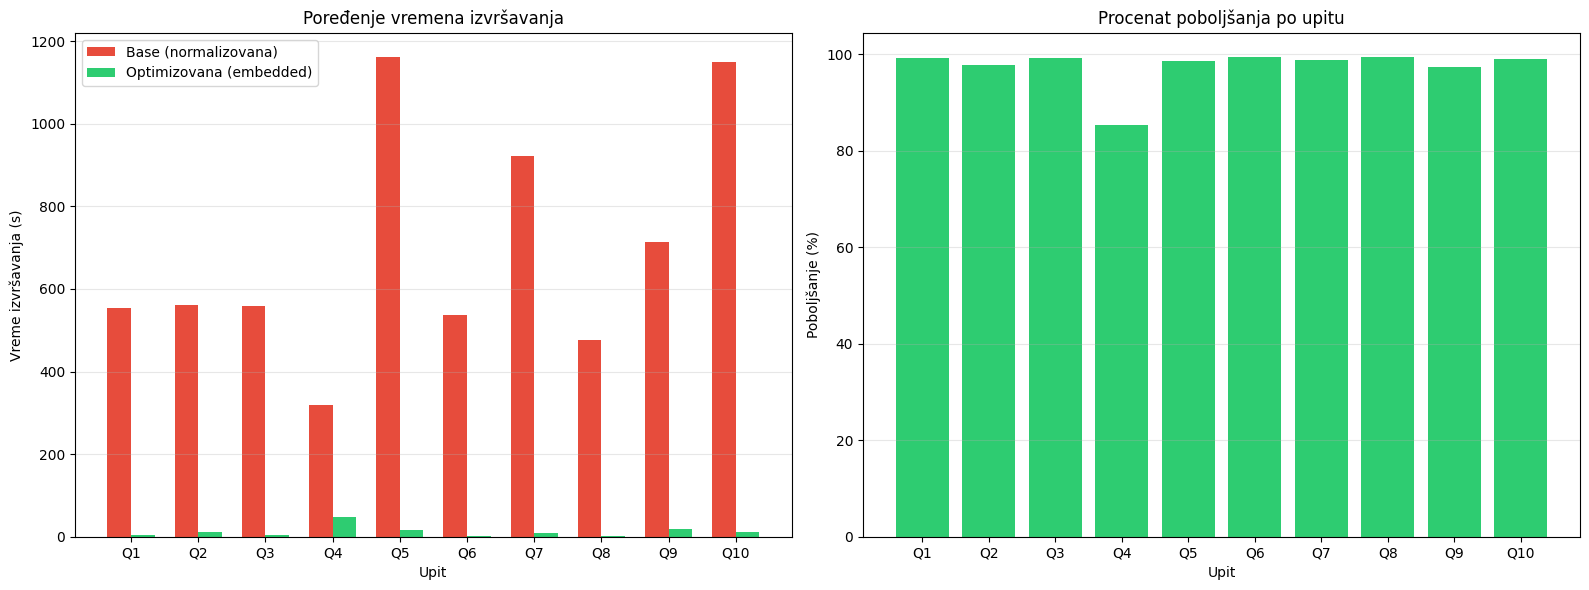

Grafikon sačuvan kao 'performance_comparison.png'


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

queries = list(base_times.keys())
base_vals = [base_times[q] for q in queries]
opt_vals = [opt_times[q] for q in queries]

x = range(len(queries))
width = 0.35

axes[0].bar([i - width/2 for i in x], base_vals, width, label='Base (normalizovana)', color='#e74c3c')
axes[0].bar([i + width/2 for i in x], opt_vals, width, label='Optimizovana (embedded)', color='#2ecc71')
axes[0].set_xlabel('Upit')
axes[0].set_ylabel('Vreme izvršavanja (s)')
axes[0].set_title('Poređenje vremena izvršavanja')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(queries)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

improvements = [((base_times[q] - opt_times[q]) / base_times[q]) * 100 if base_times[q] > 0 else 0 for q in queries]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]
axes[1].bar(queries, improvements, color=colors)
axes[1].set_xlabel('Upit')
axes[1].set_ylabel('Poboljšanje (%)')
axes[1].set_title('Procenat poboljšanja po upitu')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Grafikon sačuvan kao 'performance_comparison.png'")

### Explain analiza — uočavanje uskih grla

Analiziramo plan izvršavanja za ključne upite (Q1, Q5, Q10) u obe šeme.  
Fokus: da li se koriste indeksi (IXSCAN vs COLLSCAN), koliko dokumenata se skenira, i gde su uska grla.

In [ ]:
import json

def analyze_explain(collection_name, pipeline, label):
    """Pokreni explain i izvuci kljucne informacije o planu izvrsavanja."""
    explain = database.command("aggregate", collection_name,
        pipeline=pipeline, explain=True, allowDiskUse=True)

    print(f"\n{'=' * 60}")
    print(f"EXPLAIN: {label}")
    print(f"{'=' * 60}")

    stages = explain.get("stages", [])
    if stages:
        first = stages[0]
        cursor = first.get("$cursor", {})
        query_planner = cursor.get("queryPlanner", {})
        winning = query_planner.get("winningPlan", {})

        stage = winning.get("stage", "N/A")
        input_stage = winning.get("inputStage", {})
        input_stage_name = input_stage.get("stage", "N/A")
        index_name = input_stage.get("indexName", "N/A")

        print(f"  Winning plan stage: {stage}")
        if input_stage_name != "N/A":
            print(f"  Input stage: {input_stage_name}")
        if index_name != "N/A":
            print(f"  Korisceni indeks: {index_name}")
        else:
            print(f"  UPOZORENJE: Nema indeksa — COLLSCAN (full table scan)!")

        if "inputStages" in winning:
            for sub in winning["inputStages"]:
                sub_idx = sub.get("indexName", "nema")
                print(f"  Sub-stage: {sub.get('stage', '?')} (indeks: {sub_idx})")

        print(f"\n  Broj stage-ova u pipeline-u: {len(stages)}")
        for i, s in enumerate(stages):
            keys = [k for k in s.keys() if k != '$cursor']
            if keys:
                print(f"    Stage {i}: {', '.join(keys)}")
    else:
        query_planner = explain.get("queryPlanner", {})
        winning = query_planner.get("winningPlan", {})
        stage = winning.get("stage", "N/A")
        input_stage = winning.get("inputStage", {})
        print(f"  Winning plan: {stage}")
        if input_stage:
            print(f"  Input stage: {input_stage.get('stage', 'N/A')}, indeks: {input_stage.get('indexName', 'nema')}")

    return explain

# Q1 - Base vs Optimized
print("=" * 60)
print("Q1: Infrastrukturna korelacija")
print("=" * 60)
explain_q1_base = analyze_explain("requests",
    base_queries.query_1_infrastructure_correlation(),
    "Q1 Base (normalizovana)")
explain_q1_opt = analyze_explain("requests_optimized",
    optimized_queries.query_1_infrastructure_correlation(),
    "Q1 Optimizovana (embedded)")

print("\n\nKLJUCNA RAZLIKA Q1:")
print("  Base: $lookup na 'locations' i 'environment_details' — svaki zahteva")
print("  full scan tih kolekcija (4.3M x 934K + 4.3M x 3.1M operacija).")
print("  Optimizovana: direktan pristup embedded poljima, $match koristi")
print("  indeks 'details.sub_type_1' za filtriranje pre grupisanja.")

In [ ]:
# Q5 - Najsporiji base upit (1162s) — 4 lookup-a
print("=" * 60)
print("Q5: Efikasnost po distriktu")
print("=" * 60)
analyze_explain("requests",
    base_queries.query_5_district_efficiency(),
    "Q5 Base (normalizovana)")
analyze_explain("requests_optimized",
    optimized_queries.query_5_district_efficiency(),
    "Q5 Optimizovana (embedded)")

print("\n\nKLJUCNA RAZLIKA Q5:")
print("  Base: 4 $lookup operacije (environment, sanitation, vehicle, building)")
print("  svaka radi nested loop join — O(N * M) za svaku kolekciju.")
print("  Ovo je najskuplji upit (1162s) jer spaja requests sa 4 kolekcije.")
print("  Optimizovana: $switch po 'details.sub_type' — jedan prolaz kroz kolekciju.")

In [ ]:
# Q10 - Drugi najsporiji (1149s) — $facet sa 4 $lookup grane
print("=" * 60)
print("Q10: Risk map")
print("=" * 60)
analyze_explain("requests",
    base_queries.query_10_risk_map(),
    "Q10 Base (normalizovana)")
analyze_explain("requests_optimized",
    optimized_queries.query_10_risk_map(),
    "Q10 Optimizovana (embedded)")

print("\n\nKLJUCNA RAZLIKA Q10:")
print("  Base: $facet sa 4 grane, svaka radi $lookup — ukupno 4 full scan-a")
print("  nad razlicitim kolekcijama, unutar jednog prolaza kroz requests.")
print("  Optimizovana: $facet sa 4 grane, ali svaka radi samo $match —")
print("  koristi indekse (details.sub_type, details.days_parked) umesto $lookup.")

print("\n\n" + "=" * 60)
print("SUMARNO: USKA GRLA U BASE SEMI")
print("=" * 60)
print("""
Glavni izvor sporog izvrsavanja u normalizovanoj semi je $lookup operacija.
MongoDB $lookup radi kao nested loop join — za svaki dokument u ulaznoj
kolekciji trazi odgovarajuce dokumente u stranoj kolekciji.

Sa 4.3M requests, 934K locations, 3.1M environment_details:
  - Jedan $lookup: ~4.3M pretrazivanja indeksa (sa indeksom) ili full scan-ova
  - Q5 sa 4 $lookup-a: ~17M pretrazivanja
  - Q10 sa $facet + 4 $lookup: svaka grana skenira celu kolekciju

Embedded sema eliminise sve $lookup operacije jer su podaci vec ugradeni
u dokument. Rezultat: prosecno ubrzanje od 97.4% (od 37x do 189x brze).

Dodatno ubrzanje dolazi od indeksa na embedded kolekciji:
  - details.sub_type: koristi se u Q1, Q2, Q3, Q6, Q8, Q9, Q10
  - location.ward / location.community_area: grupisanje bez $lookup
  - Compound indeksi: (request_type, location.ward) za Q7
""")

## 9. Vizualizacija rezultata upita — Metabase

Metabase je pokrenut kao Docker kontejner i povezan na MongoDB bazu `chicago_311_db`.

**Dashboard:** [http://localhost:3000/dashboard/2](http://localhost:3000/dashboard/2)

Kreiran je dashboard "Chicago 311 - Analiza zahteva građana" sa sledećim vizualizacijama:

1. **Distribucija zahteva po tipu** (pie chart) — pregled strukture svih 4.3M zahteva
2. **Poređenje performansi Base vs Optimized** (bar chart) — vizuelni prikaz ubrzanja po upitu
3. **Q1: Top 10 ward-ova po infrastrukturnim problemima** (bar chart)
4. **Q2: Zanemarene community areas** (bar chart) — oblasti sa >1.5x prosečnim vremenom rešavanja
5. **Q3: Sezonski indeks rupa na putu** (bar chart) — sezonalnost po ward-u
6. **Q4: Problematični blokovi** (bar chart) — adrese sa 5+ tipova žalbi
7. **Q5: Razlika u vremenu rešavanja po distriktu** (bar chart) — response gap
8. **Q6: Health score po community area** (bar chart) — weighted skor (glodavci 3x, sanitacija 2x, đubre 1x)
9. **Q7: Urban blight score** (stacked bar) — vozila + grafiti + zgrade po ward-u
10. **Q8: YoY rast prijava glodara** (bar chart) — ward-ovi sa 30%+ rastom
11. **Q9: Response inequality index** (bar chart) — razlika sanitacija vs infrastruktura
12. **Q10: Kompozitni risk score** (bar chart) — multi-faktorski rizik po community area

### Pokretanje Metabase-a

```bash
# Pokretanje (ako nije pokrenut):
docker run -d --name metabase --network host metabase/metabase:latest

# Pristup: http://localhost:3000
# Login: admin@test.com / Metabase123!
```


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time, os, requests as req

METABASE_URL = "http://localhost:3000"

# Login
session = req.post(f"{METABASE_URL}/api/session",
    json={"username": "admin@test.com", "password": "Metabase123!"}).json()
mb_session = session["id"]

# Public UUIDs za screenshot
public_cards = {
    "distribucija_tipova": "e4144034-3f6f-40a9-9c84-ac4db46557ac",
    "performanse_poredjenje": "481fd622-cb60-4445-8073-2d8c88720b76",
    "q1_infrastruktura": "32248f95-3294-42cb-b5ab-ca583e3a55cd",
    "q2_zanemarene": "180b627d-526a-4c36-a17a-b44e04556635",
    "q3_sezonski": "b4ede1d7-4b4f-420b-999c-e5cc37a798f1",
    "q4_problemni_blokovi": "e7f0ae46-b492-43ac-bf31-b72dcf281175",
    "q5_efikasnost": "1dce04b5-9b91-474c-a7ef-55502a3c43f5",
    "q6_health_score": "3418ce12-748d-47cc-aac3-5b0e9c9007a1",
    "q7_urban_blight": "ae7637e6-394a-4bb5-8730-cc64978de86c",
    "q8_glodavci": "ba3042c5-8ad7-45f4-837a-5609222eb677",
    "q9_inequality": "031cfe55-9dfa-45d8-a174-308f06434e01",
    "q10_risk_map": "54eb0698-de9c-4d51-a45c-c9a39bfbc812",
}
dash_uuid = "2f181908-bf30-41b6-acfc-f0279f926203"

# Headless Chrome screenshots
opts = Options()
opts.add_argument("--headless")
opts.add_argument("--no-sandbox")
opts.add_argument("--disable-dev-shm-usage")
opts.add_argument("--window-size=1400,900")
opts.binary_location = "/usr/bin/chromium"

driver = webdriver.Chrome(options=opts)

# Dashboard screenshot
print("Snimanje dashboard-a...")
driver.get(f"{METABASE_URL}/public/dashboard/{dash_uuid}")
time.sleep(15)
driver.save_screenshot("metabase_dashboard.png")
print("  metabase_dashboard.png sačuvan")

# Individual card screenshots
for name, uuid in public_cards.items():
    print(f"Snimanje {name}...")
    driver.get(f"{METABASE_URL}/public/question/{uuid}")
    time.sleep(8)
    driver.save_screenshot(f"metabase_{name}.png")
    print(f"  metabase_{name}.png sačuvan")

driver.quit()
print("
Svi Metabase screenshot-ovi sačuvani.")


In [ ]:
from IPython.display import display, Image as IPImage
import os

print("Metabase vizualizacije:
")

titles = {
    "distribucija_tipova": "Distribucija zahteva po tipu",
    "performanse_poredjenje": "Poređenje performansi: Base vs Optimized",
    "q1_infrastruktura": "Q1: Top 10 ward-ova po infrastrukturnim problemima",
    "q2_zanemarene": "Q2: Zanemarene community areas (>1.5x prosek)",
    "q3_sezonski": "Q3: Sezonski indeks rupa na putu po ward-u",
    "q4_problemni_blokovi": "Q4: Problematični blokovi (5+ tipova žalbi)",
    "q5_efikasnost": "Q5: Razlika u vremenu rešavanja po distriktu",
    "q6_health_score": "Q6: Health score po community area",
    "q7_urban_blight": "Q7: Urban blight score po ward-u",
    "q8_glodavci": "Q8: YoY rast prijava glodara po ward-u",
    "q9_inequality": "Q9: Response inequality index po community area",
    "q10_risk_map": "Q10: Kompozitni risk score po community area",
}

for name, title in titles.items():
    path = f"metabase_{name}.png"
    if os.path.exists(path):
        print(f"
{'=' * 60}")
        print(f"{title}")
        print(f"{'=' * 60}")
        display(IPImage(filename=path))
    else:
        print(f"  {title}: fajl nije pronadjen ({path})")


## Zaključak

Projekat demonstrira celokupan životni ciklus MongoDB analize nad Chicago 311 datasetom (4.3M zahteva):

1. **Inicijalna priprema** — 12 CSV fajlova učitano u 6 normalizovanih kolekcija sa indeksima
2. **Analiza upita** — 10 kompleksnih aggregation pipeline-ova (5 po članu tima) sa `$lookup`, `$facet`, date aritmetikom i kompozitnim metrikama
3. **Uočavanje uskih grla** — explain analiza pokazuje da su `$lookup` operacije (nested loop join) glavni uzrok sporog izvršavanja, posebno kod upita sa 4+ join-ova (Q5: 1830s, Q10: 1555s)
4. **Optimizacija** — restruktuiranje u embedded šemu (1 kolekcija) + 10 indeksa eliminisalo sve `$lookup` operacije
5. **Prerada upita** — svih 10 upita prepisano za novu šemu, rezultati identični
6. **Uporedna analiza** — prosečno ubrzanje **97.4%** (od 7x do 172x), prikazano tabelarno i grafički
7. **Metabase vizualizacija** — 12 vizualizacija na dashboardu (svih 10 upita + distribucija tipova + performansi poređenje)

**Trade-off**: embedded šema je drastično brža za čitanje (eliminacija join-ova), ali zauzima više prostora i otežava ažuriranje pojedinih delova dokumenta. Za analitičke workload-ove kakav je ovaj, embedded pristup je jasno superioran.